In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\potfolio\Fraud_Detection\data\raw\Base.csv")
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [3]:
df.memory_usage(deep=True).sum() / 1024**3

0.4849591702222824

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [5]:
df.shape

(1000000, 32)

In [6]:
df.describe()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,...,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,...,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,...,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,...,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,...,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,...,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,...,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


In [7]:
date_columns = [  col  for col in df.columns if "date" in col.lower() or "time" in col.lower() ]
date_columns

['date_of_birth_distinct_emails_4w']

In [8]:
numeric_columns = df.drop("fraud_bool", axis=1)
numeric_columns = numeric_columns.select_dtypes(include=["int64","float64"]).columns


In [9]:
df[numeric_columns].head()

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0.3,0.986506,-1,25,40,0.006735,102.453711,1059,13096.035018,7850.955007,...,1,9,0,1500.0,0,16.224843,1,1,0,0
1,0.8,0.617426,-1,89,20,0.010095,-0.849551,1658,9223.283431,5745.251481,...,1,2,0,1500.0,0,3.363854,1,1,0,0
2,0.8,0.996707,9,14,40,0.012316,-1.490386,1095,4471.472149,5471.988958,...,1,30,0,200.0,0,22.730559,0,1,0,0
3,0.6,0.475100,11,14,30,0.006991,-1.863101,3483,14431.993621,6755.344479,...,1,1,0,200.0,0,15.215816,1,1,0,0
4,0.9,0.842307,-1,29,40,5.742626,47.152498,2339,7601.511579,5124.046930,...,1,26,0,200.0,0,3.743048,0,1,0,0


In [10]:
cat_cols = df.select_dtypes(include=["object"]).columns.to_list()
df[cat_cols].head()

,payment_type,employment_status,housing_status,source,device_os
0,AA,CB,BC,INTERNET,linux
1,AD,CA,BC,INTERNET,other
2,AB,CA,BC,INTERNET,windows
3,AB,CA,BC,INTERNET,linux
4,AA,CA,BC,INTERNET,other


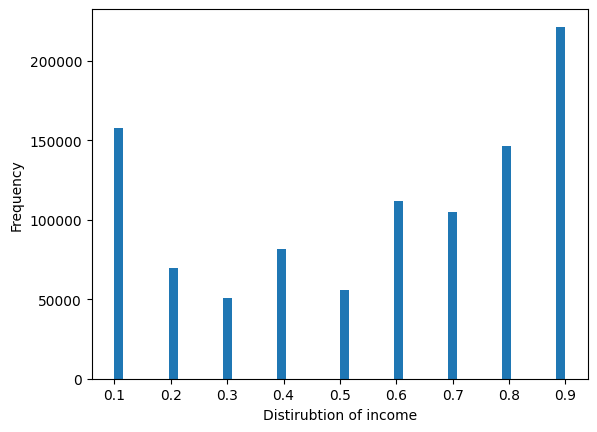

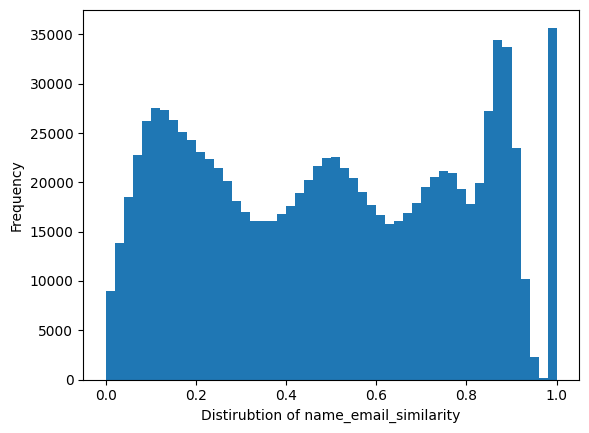

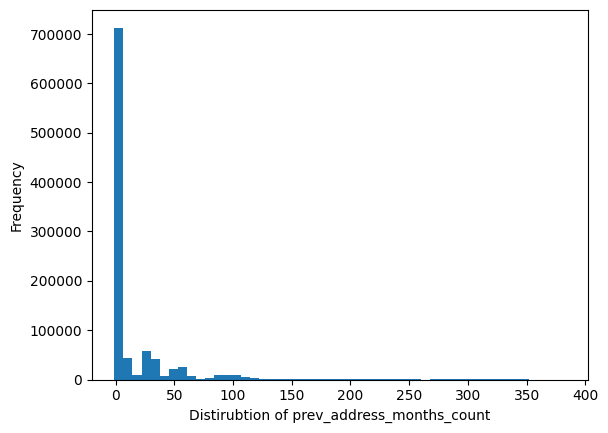

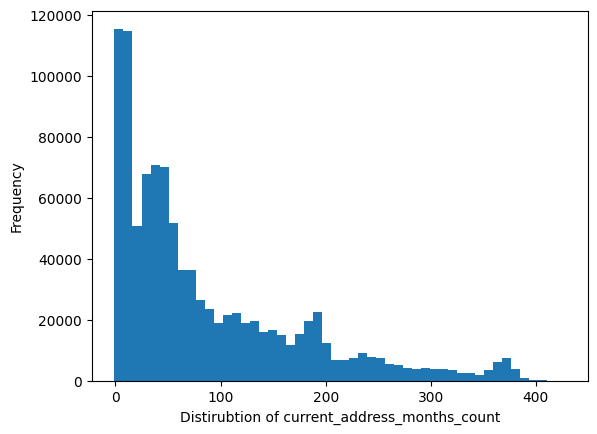

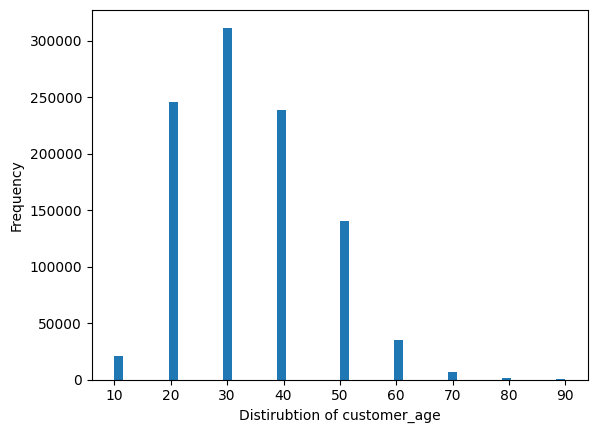

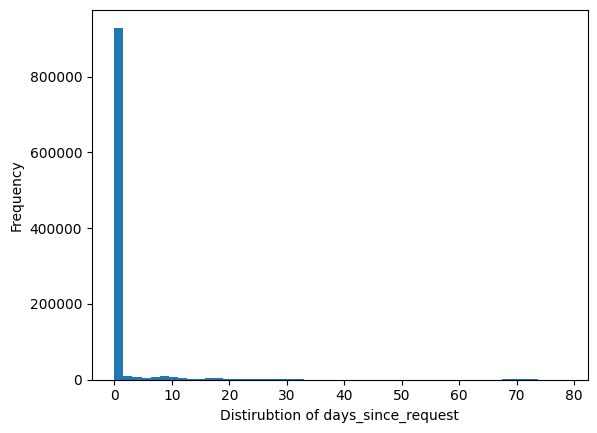

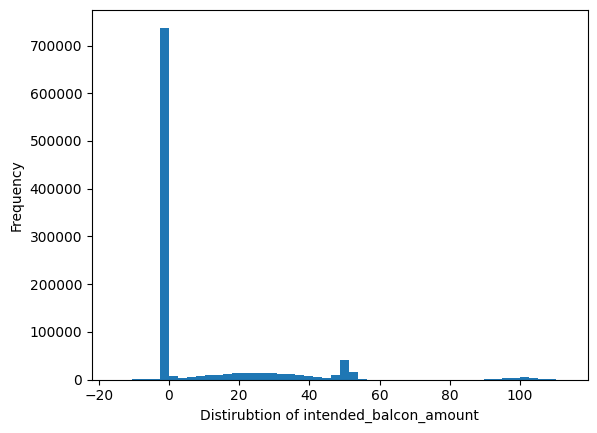

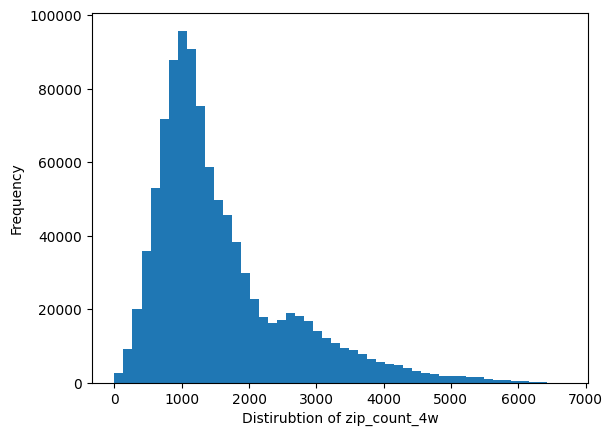

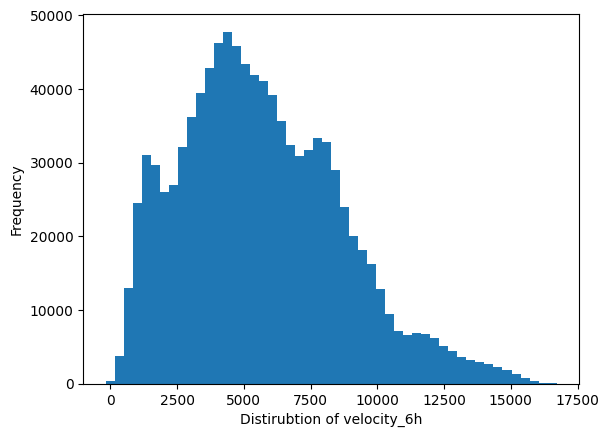

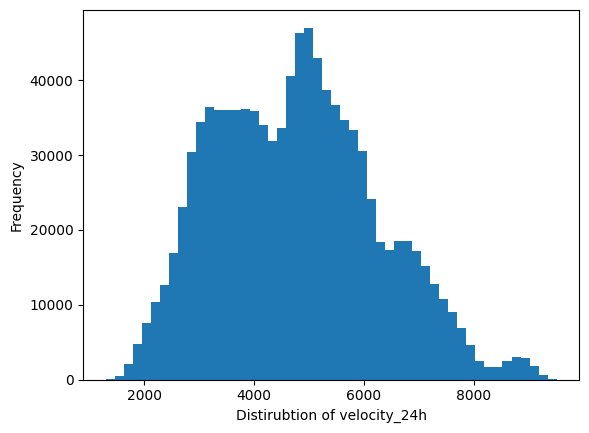

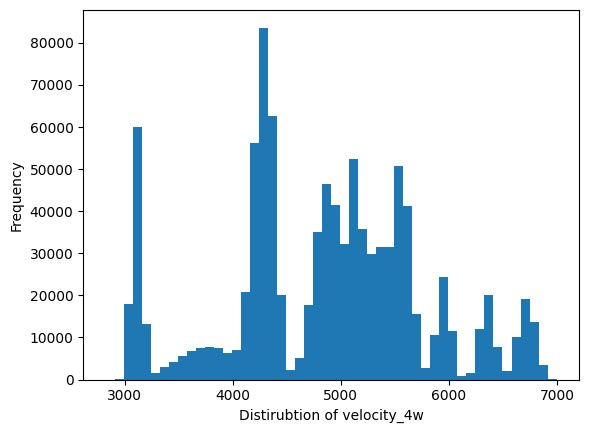

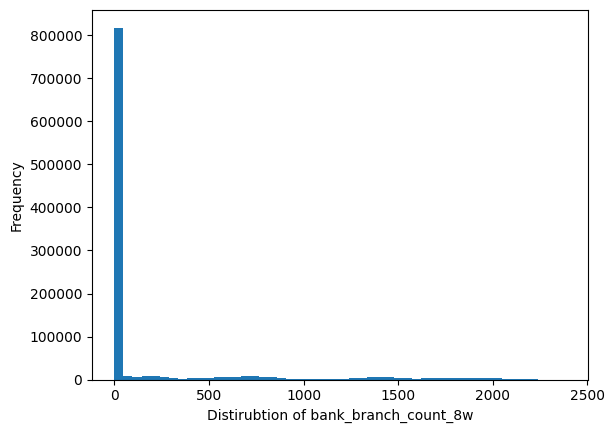

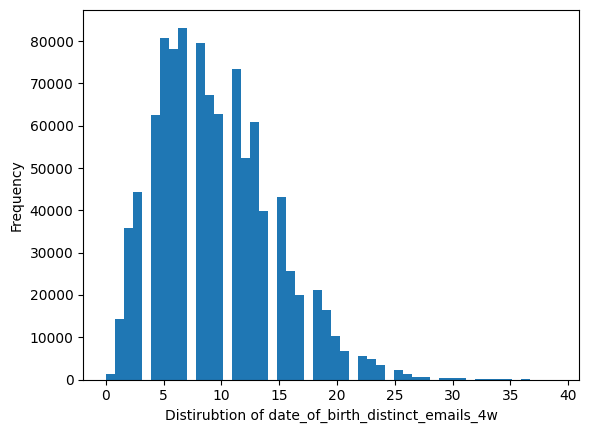

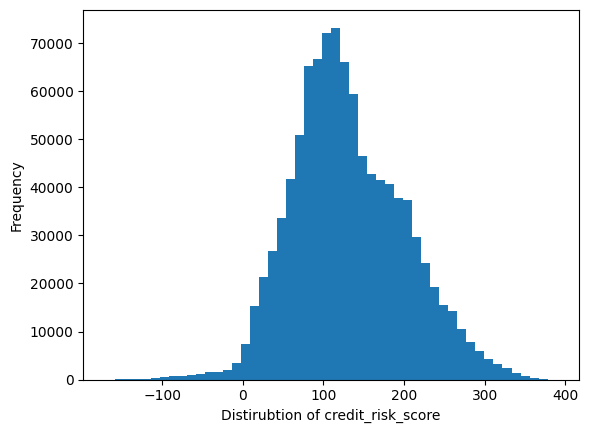

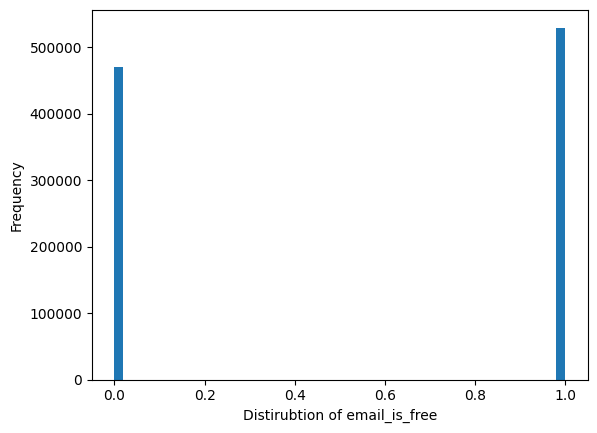

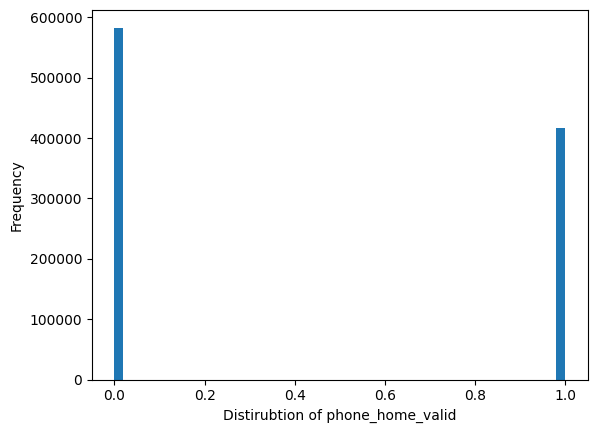

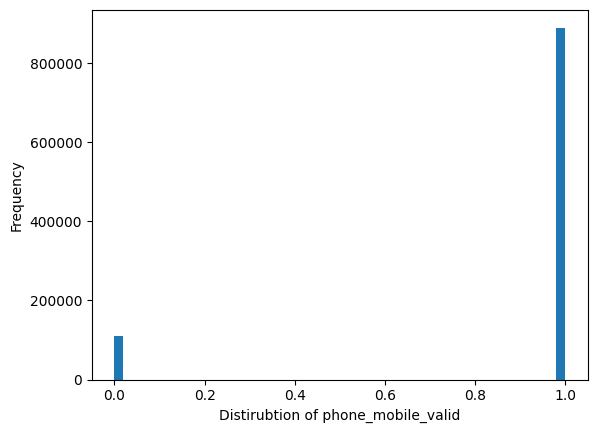

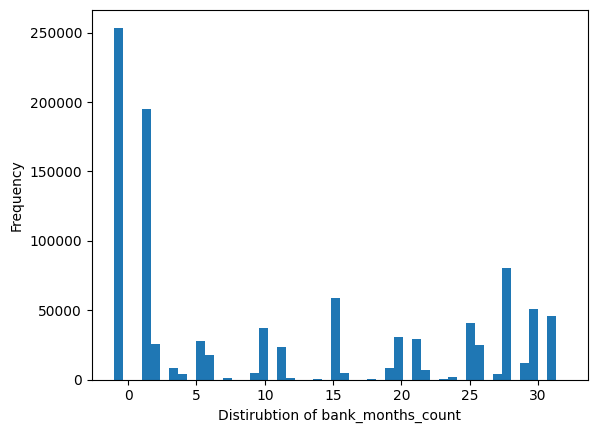

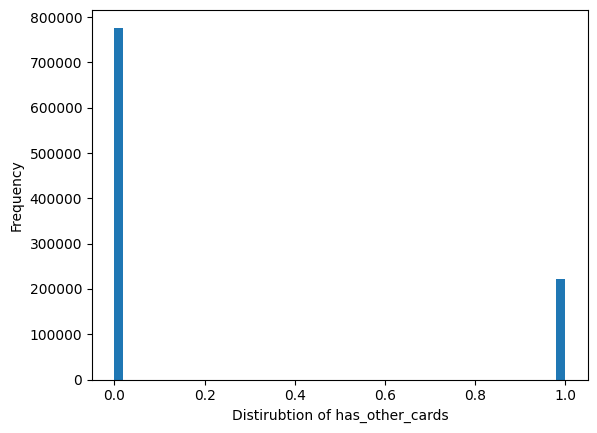

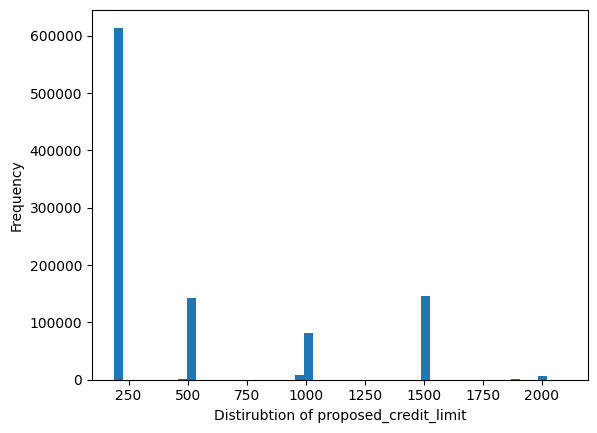

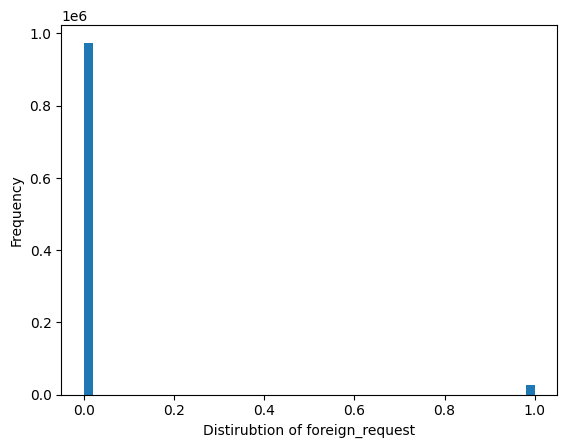

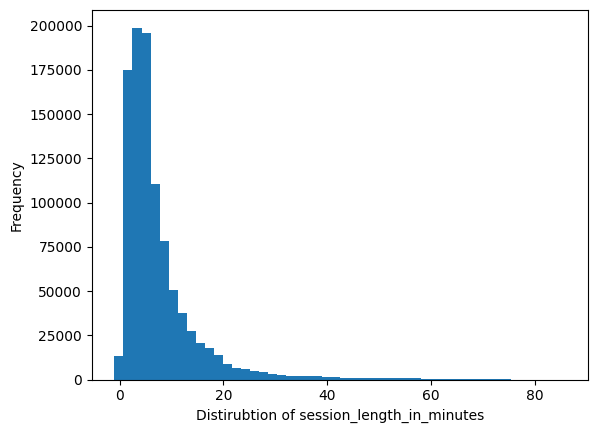

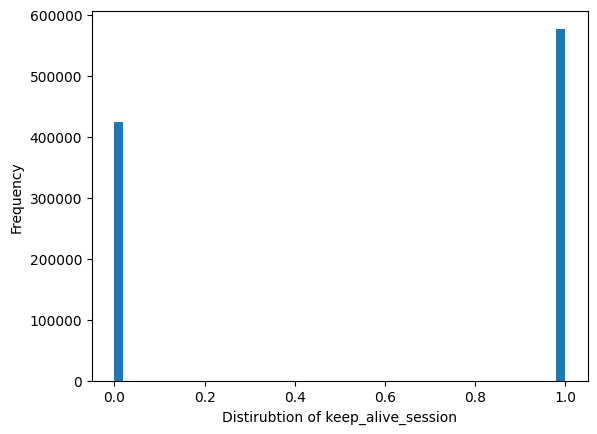

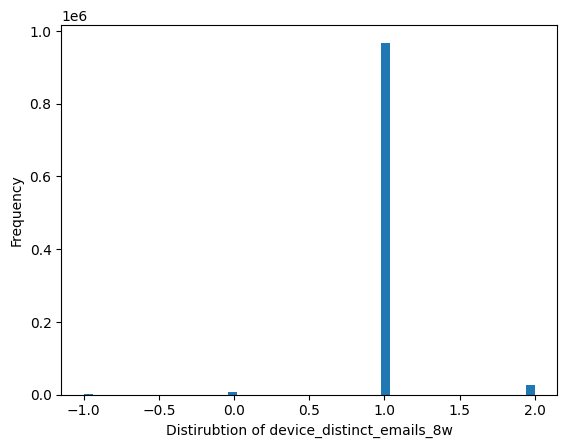

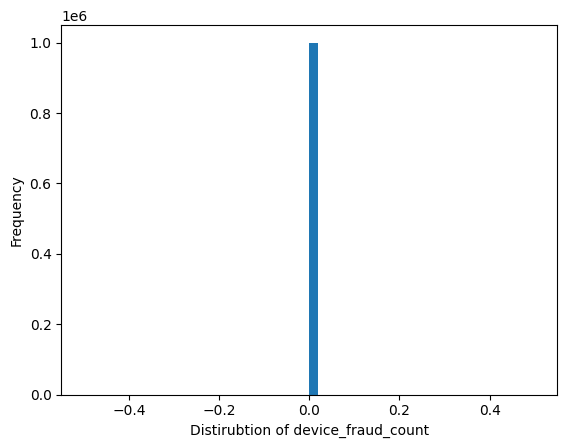

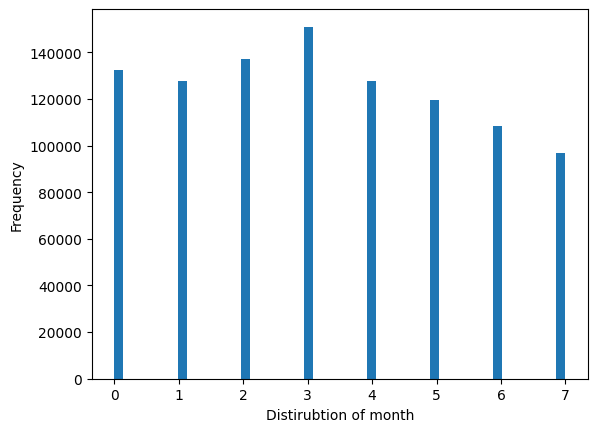

In [11]:
for i in numeric_columns:
    plt.hist(df[i],bins=50)
    plt.xlabel(f"Distirubtion of {i}")
    plt.ylabel("Frequency")
    plt.Figure(figsize=(25,6))
    plt.show()

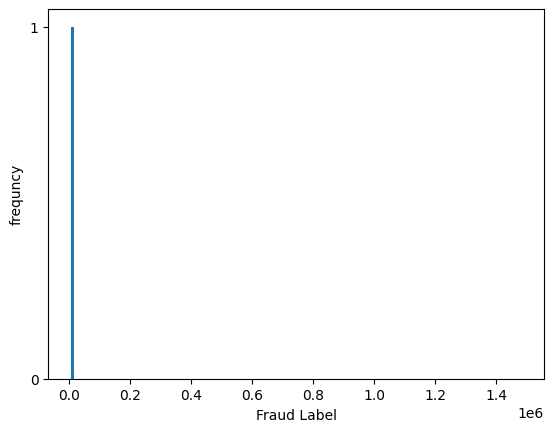

In [12]:
count = df["fraud_bool"].value_counts()

plt.bar(count, count.index.astype(str),  count.values)
plt.xlabel("Fraud Label")
plt.ylabel("frequncy")
plt.show()

In [13]:
skewness = {}

for  i in numeric_columns:
    skewness[i] = df[i].skew()

In [14]:
skew = pd.DataFrame(skewness, columns=["features"], index=None)
skew["features"] = skewness.keys()
skew["values"] = skewness.values()
skew.sort_values(by="values", ascending=False)

,features,values
5,days_since_request,9.278955
20,foreign_request,6.053306
2,prev_address_months_count,4.063888
21,session_length_in_minutes,3.304575
11,bank_branch_count_8w,2.747161
6,intended_balcon_amount,2.507173
23,device_distinct_emails_8w,2.430764
7,zip_count_4w,1.456657
3,current_address_months_count,1.386998
18,has_other_cards,1.330989


In [15]:
skew_df = pd.DataFrame.from_dict(skewness, orient='index', columns=['skew'])
skew_df.sort_values(by='skew', ascending=False)

,skew
days_since_request,9.278955
foreign_request,6.053306
prev_address_months_count,4.063888
session_length_in_minutes,3.304575
bank_branch_count_8w,2.747161
intended_balcon_amount,2.507173
device_distinct_emails_8w,2.430764
zip_count_4w,1.456657
current_address_months_count,1.386998
has_other_cards,1.330989


In [16]:
fraud_month = df.groupby("month").agg({
    "fraud_bool" : ["mean", "sum"]
}).reset_index()
new_columns = ["month","fraud_bool_mean", "fraud_bool_sum"]
fraud_month.columns = new_columns
fraud_month

,month,fraud_bool_mean,fraud_bool_sum
0,0,0.011326,1500
1,1,0.009387,1198
2,2,0.008746,1198
3,3,0.009222,1392
4,4,0.011371,1452
5,5,0.011825,1411
6,6,0.013405,1450
7,7,0.014746,1428


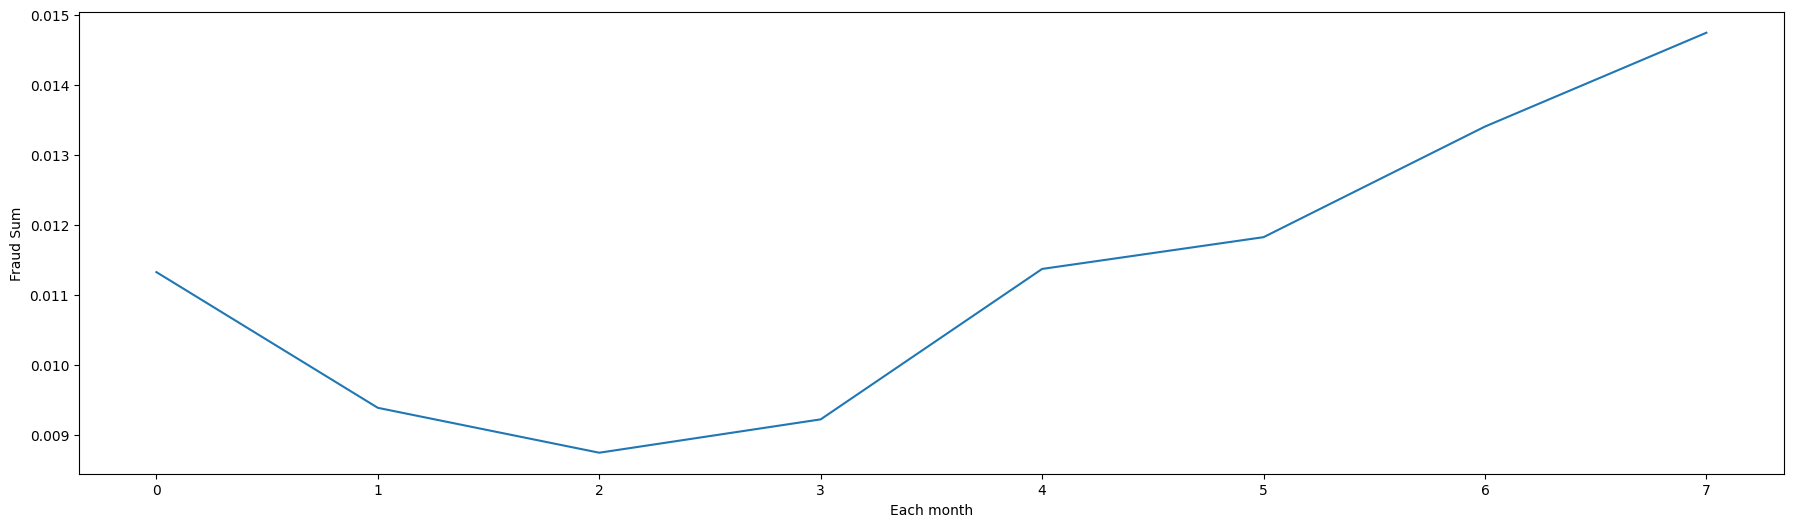

In [17]:
plt.figure(figsize=(22,6))
plt.plot(fraud_month["month"] ,fraud_month["fraud_bool_mean"])
plt.xlabel("Each month")
plt.ylabel("Fraud Sum")
plt.show()

In [18]:
import plotly.graph_objects as go 

fig = go.Figure()

fig.add_traces(
    go.Scatter(
        x= fraud_month["month"],
        y = fraud_month["fraud_bool_mean"],
        mode = "lines",
        name ="Fraud Mean per Month"
    )
)
fig.update_layout(
    title="Line Plot of Fraud Mean per Month",
    xaxis_title="Month",
    yaxis_title="Fraud Mean"
)
fig.show()


In [19]:
import plotly.express as px

In [20]:
for col in cat_cols:
    counts = df[col].value_counts().reset_index()
    counts.columns = [col,"count"]
    fig = px.bar(
        counts.head(20), x = col, y = "count", title=f"Top categories of {col}"
    )
    # fig.show()

In [21]:
each_cat_count = {} 

for i in cat_cols:
    each_cat_count[i] = df[i].nunique()

each_cat_count

{'payment_type': 5,
 'employment_status': 7,
 'housing_status': 7,
 'source': 2,
 'device_os': 5}

**Bivariant Analysis starts from  here**

In [22]:
numeric_columns

Index(['income', 'name_email_similarity', 'prev_address_months_count',
       'current_address_months_count', 'customer_age', 'days_since_request',
       'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'credit_risk_score',
       'email_is_free', 'phone_home_valid', 'phone_mobile_valid',
       'bank_months_count', 'has_other_cards', 'proposed_credit_limit',
       'foreign_request', 'session_length_in_minutes', 'keep_alive_session',
       'device_distinct_emails_8w', 'device_fraud_count', 'month'],
      dtype='object')

In [23]:
print(min(df["customer_age"]),max(df["customer_age"]))

10 90


In [24]:
def apply_age(age):
    if 10 <= age < 20:
        return "10-20"
    elif 20 <= age < 30:
        return "21-30"
    elif 30 <= age < 40:
        return "31-40"
    elif 40 <= age < 50:
        return "41-50"
    elif 50 <= age < 60:
        return "51-60"
    else:
        return "Above 60"

In [25]:

df["age_group"] = df["customer_age"].apply(apply_age)

In [26]:
pd.set_option("display.max_columns", None)
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,age_group
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0,41-50
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0,21-30
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0,41-50
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0,31-40
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0,41-50


In [27]:
df["customer_age"].value_counts()

customer_age
30    311433
20    245855
40    238712
50    140353
60     34770
10     20987
70      6517
80      1297
90        76
Name: count, dtype: int64

In [28]:
df["fraud_bool"]

0         0
1         0
2         0
3         0
4         0
         ..
999995    0
999996    0
999997    0
999998    0
999999    0
Name: fraud_bool, Length: 1000000, dtype: int64

In [29]:
fraud_based_on_age = df.groupby(["age_group","fraud_bool"]).agg({
    "fraud_bool" : ["mean", "count"],
    "income" : ["mean", "sum"]
}).reset_index()
fraud_based_on_age.columns = ["age_group","fraud_bool","fraud_bool_mean", "fraud_bool_count", "income_mean","income_sum"]
fraud_based_on_age

,age_group,fraud_bool,fraud_bool_mean,fraud_bool_count,income_mean,income_sum
0,10-20,0,0.0,20913,0.421417,8813.1
1,10-20,1,1.0,74,0.504054,37.3
2,21-30,0,0.0,244650,0.499295,122152.5
3,21-30,1,1.0,1205,0.623154,750.9
4,31-40,0,0.0,308844,0.566164,174856.4
5,31-40,1,1.0,2589,0.677443,1753.9
6,41-50,0,0.0,235836,0.610284,143926.9
7,41-50,1,1.0,2876,0.716099,2059.5
8,51-60,0,0.0,137548,0.597359,82165.5
9,51-60,1,1.0,2805,0.701783,1968.5


In [30]:
fig = px.scatter(
    fraud_based_on_age,
    x="age_group",
    y="fraud_bool_count",
    color="fraud_bool",
    size="fraud_bool_count",
    title="Fraud Rate Comparison Between Fraud : 0 and Fraud : 1 for Each Age Group"
)

fig.update_layout(
    xaxis_title="Age Group",
    yaxis_title="Fraud Rate",
    height=600,
    width=1000
)

fig.show()


In [31]:
fig  = go.Figure()

fig.add_traces(
    go.Scatter(
        x=fraud_based_on_age["age_group"],
        y=fraud_based_on_age["income_mean"],
        mode = "markers+lines"
    )
)
fig.update_layout(
    title = "Age and income Correaltion",
    xaxis_title = "Customer Age",
    yaxis_title = "Customer Income"
)
fig.show()

In [32]:
numeric_correlation = df[numeric_columns].corr()
numeric_correlation

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
income,1.000000,-0.038519,0.018209,-0.036985,0.125822,-0.015877,0.059046,-0.080581,-0.096431,-0.101269,-0.106333,0.007474,-0.062348,0.171447,-0.024900,0.024938,0.014979,-0.004514,0.086861,0.108868,0.011452,-0.055430,-0.043584,-0.009992,NaN,0.116479
name_email_similarity,-0.038519,1.000000,-0.018186,0.050305,-0.048902,-0.007736,0.029040,0.025114,0.024881,0.035221,0.039968,-0.001470,0.022994,0.049126,-0.066897,-0.002931,0.008966,-0.006351,0.011021,0.073159,-0.015224,0.005998,0.014342,-0.017804,NaN,-0.042949
prev_address_months_count,0.018209,-0.018186,1.000000,-0.271730,-0.069178,0.078107,-0.009428,-0.029638,-0.001265,0.009020,0.005413,-0.040628,0.059560,-0.016104,-0.014348,-0.053353,0.004757,-0.045550,-0.042949,-0.028474,0.019242,0.051425,0.031672,0.011924,NaN,-0.001793
current_address_months_count,-0.036985,0.050305,-0.271730,1.000000,0.142863,-0.057836,0.057601,0.047286,0.027508,0.018753,0.026172,0.054202,-0.174714,0.094976,-0.079519,0.129102,-0.088268,0.071997,0.060732,0.130594,-0.012355,-0.033574,-0.050539,-0.000760,NaN,-0.024541
customer_age,0.125822,-0.048902,-0.069178,0.142863,1.000000,-0.035999,-0.013000,-0.014176,-0.022063,-0.010030,-0.004303,0.048412,-0.420173,0.166094,-0.000357,0.212713,-0.147098,0.012907,0.108743,0.148857,-0.001606,0.025049,-0.024272,0.025709,NaN,0.005694
days_since_request,-0.015877,-0.007736,0.078107,-0.057836,-0.035999,1.000000,0.019782,0.000249,0.027968,0.023869,0.017706,-0.018173,0.018731,-0.088141,0.008163,-0.042009,0.005130,-0.027460,-0.048861,-0.068670,0.001066,0.049613,0.000337,0.009025,NaN,-0.017938
intended_balcon_amount,0.059046,0.029040,-0.009428,0.057601,-0.013000,0.019782,1.000000,0.002251,0.042849,0.064080,0.051407,0.102919,-0.027343,0.002058,-0.014754,0.000019,0.038625,0.178374,0.096676,0.057860,0.007933,0.022811,-0.020689,-0.019910,NaN,-0.043070
zip_count_4w,-0.080581,0.025114,-0.029638,0.047286,-0.014176,0.000249,0.002251,1.000000,0.142372,0.201186,0.302955,0.005958,0.126885,-0.102645,0.021731,-0.035661,0.012122,0.053637,-0.015015,-0.011651,0.017212,0.039687,0.022283,0.020550,NaN,-0.287203
velocity_6h,-0.096431,0.024881,-0.001265,0.027508,-0.022063,0.027968,0.042849,0.142372,1.000000,0.464003,0.400254,0.020140,0.118752,-0.145254,0.028379,-0.036820,-0.010751,0.014874,-0.007049,-0.025005,-0.000450,0.054491,0.002797,0.030030,NaN,-0.409148
velocity_24h,-0.101269,0.035221,0.009020,0.018753,-0.010030,0.023869,0.064080,0.201186,0.464003,1.000000,0.539115,0.036062,0.155434,-0.146770,0.033543,-0.052699,-0.029432,0.018855,-0.030688,0.017725,0.015419,0.066875,-0.000567,0.034981,NaN,-0.549919


In [33]:
fig = go.Figure(
    data = go.Heatmap(
        z = numeric_correlation.values,              # correlation values
        x = numeric_correlation.columns,             # column names
        y = numeric_correlation.columns,             # row names
        colorscale = "RdBu",                         # blue → negative, red → positive
        zmin = -1, zmax = 1                          # keep scale consistent
    )
)

fig.update_layout(
    title = "Correlation Matrix (Numeric Variables)",
    width = 900,
    height = 900
)

fig.show()

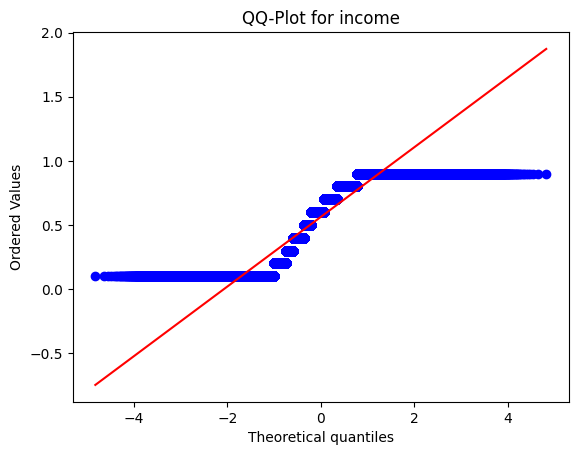

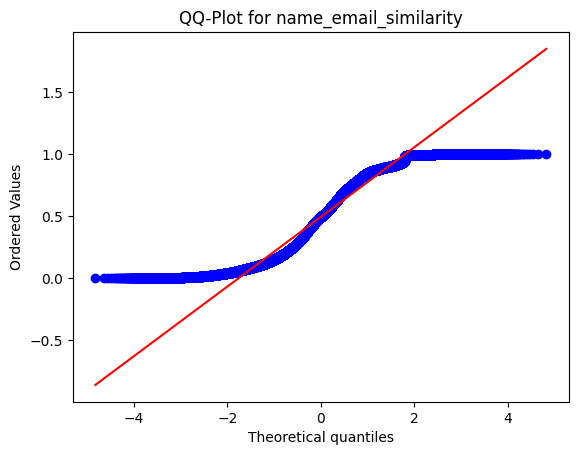

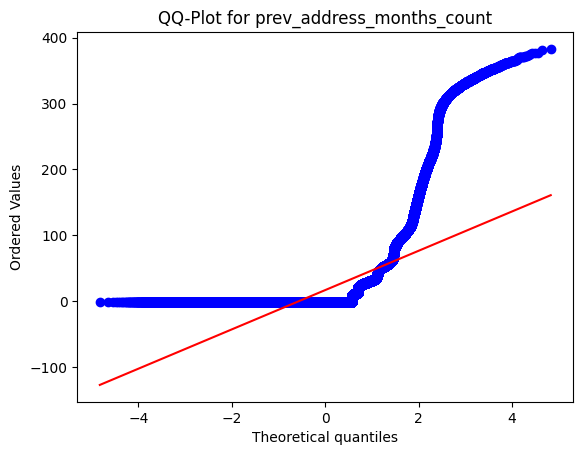

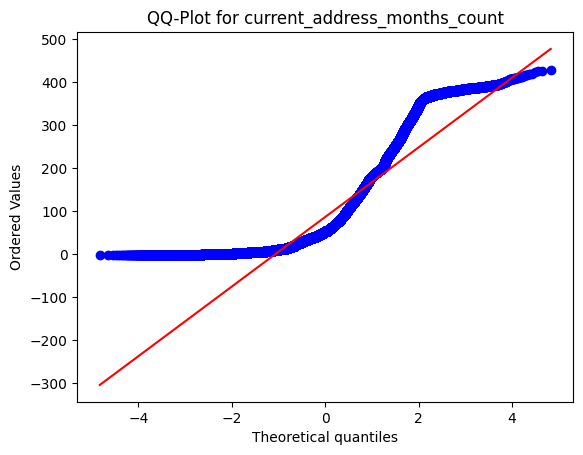

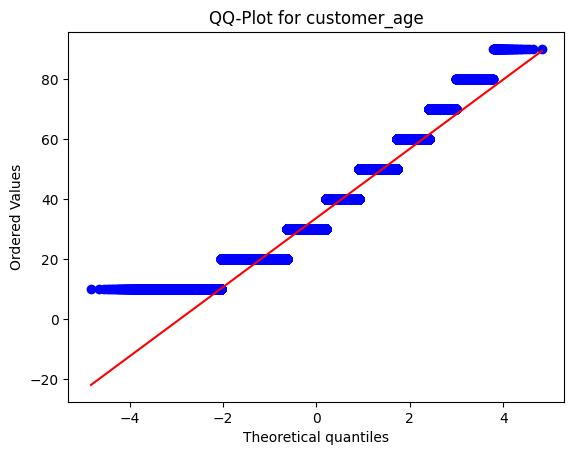

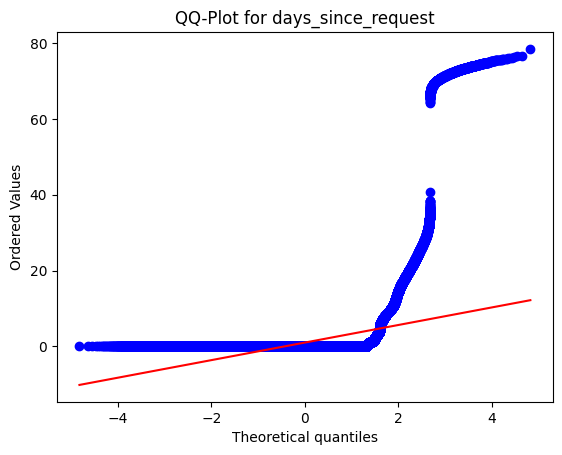

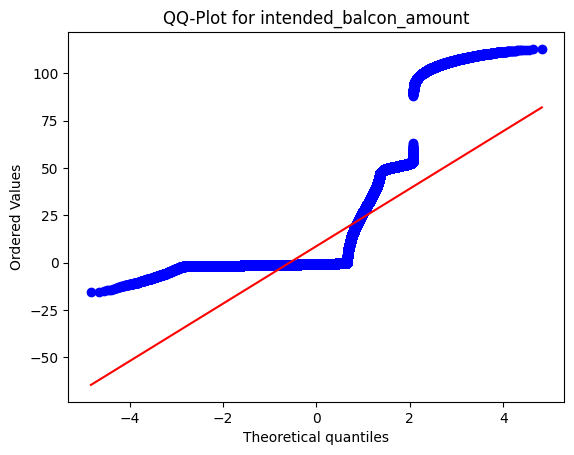

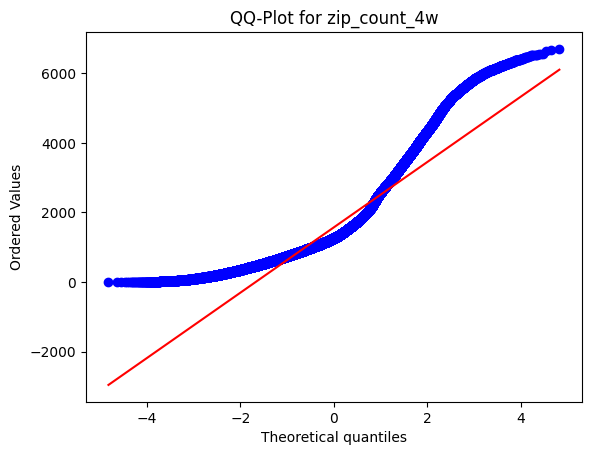

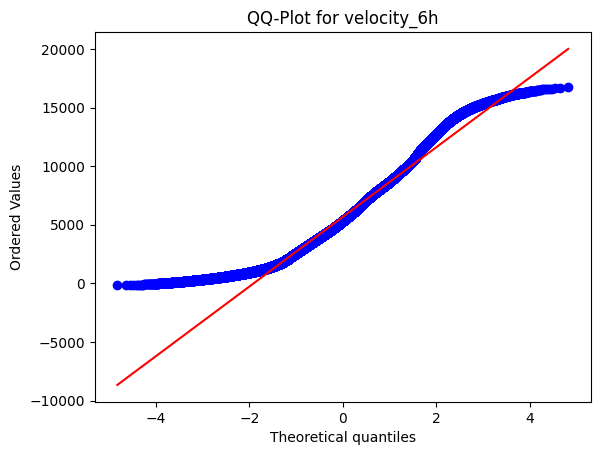

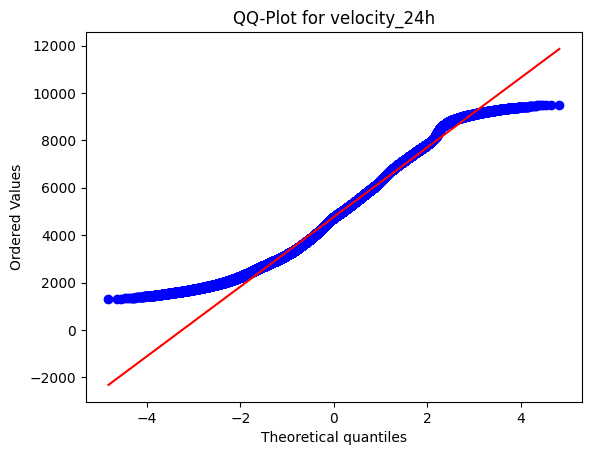

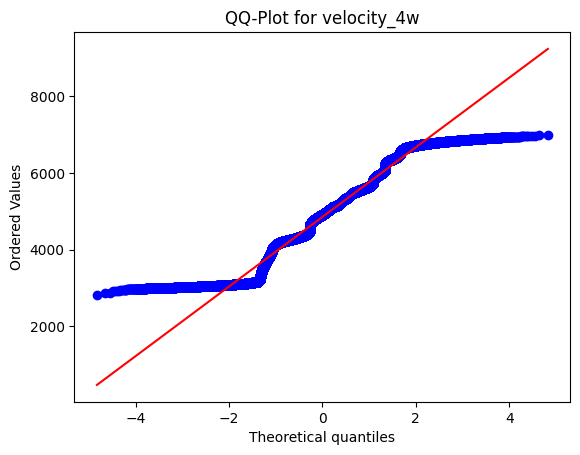

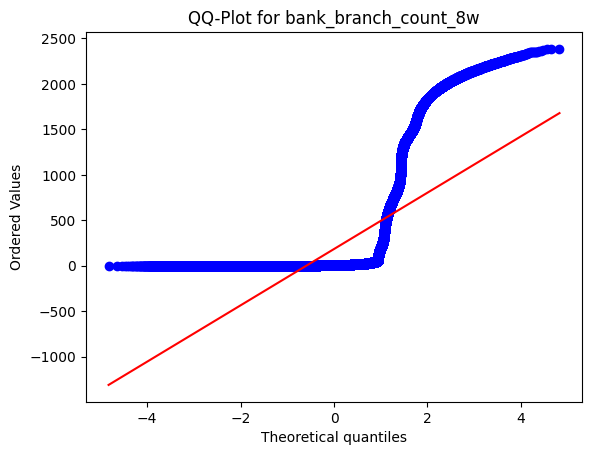

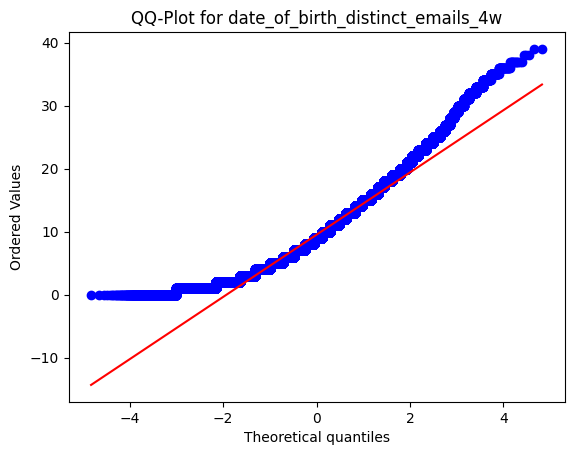

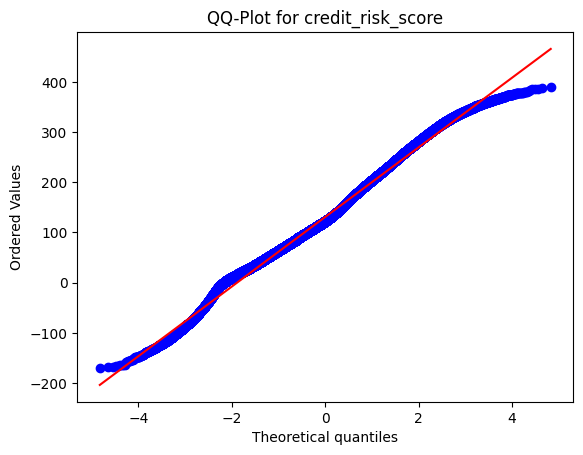

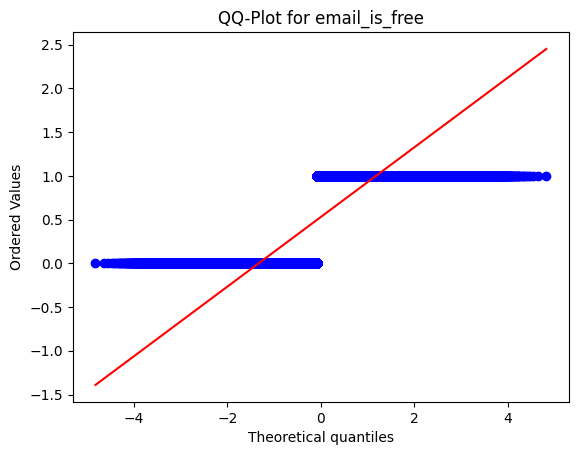

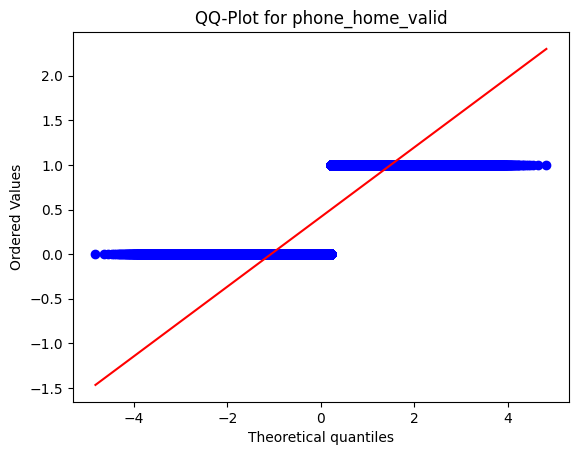

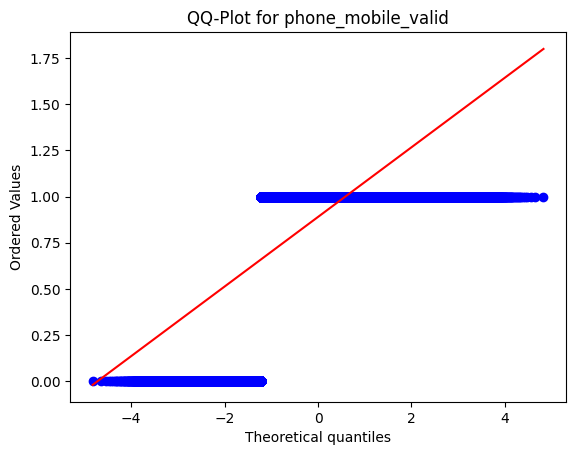

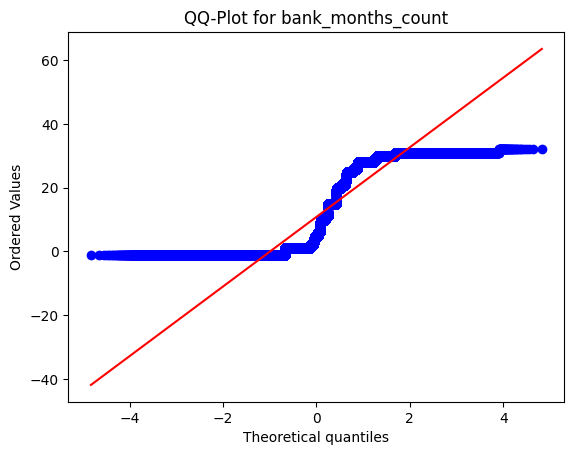

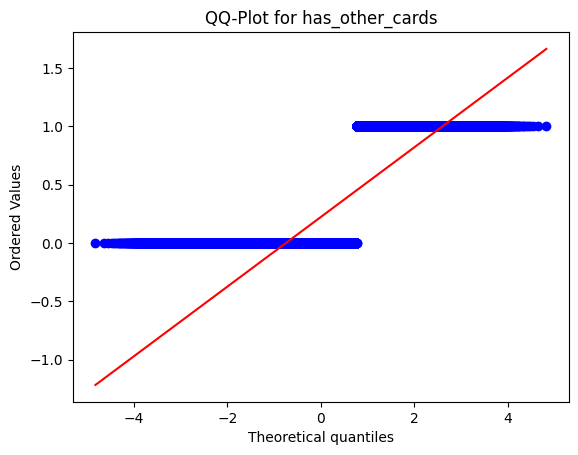

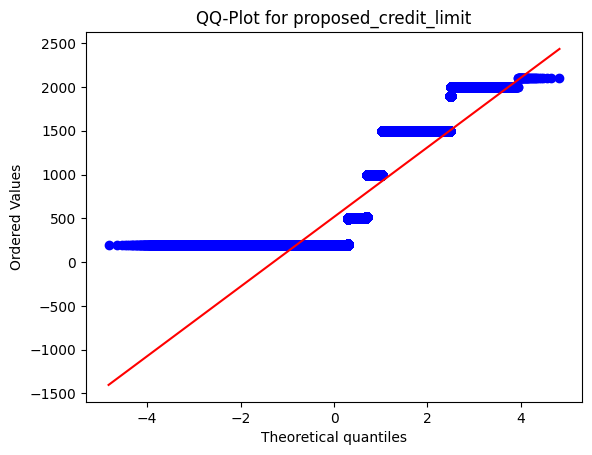

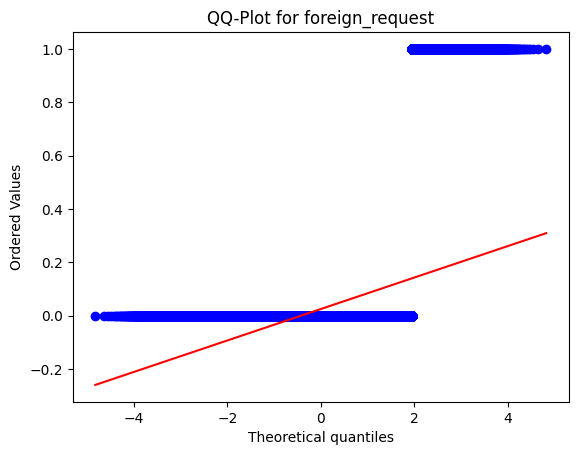

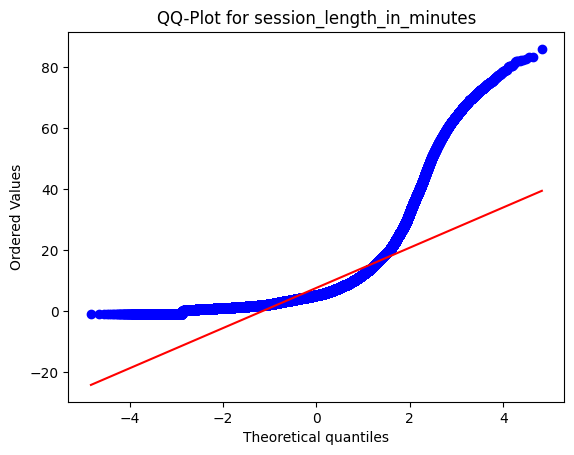

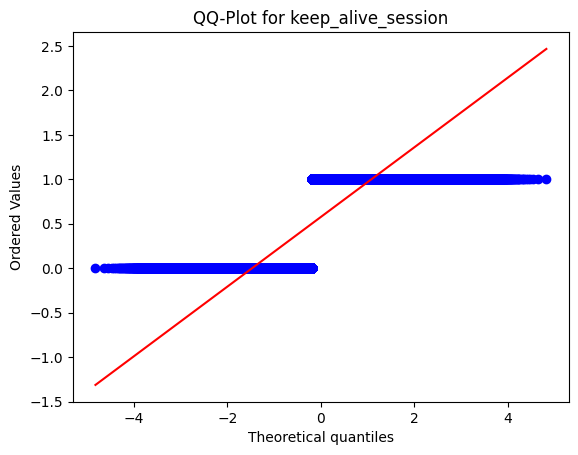

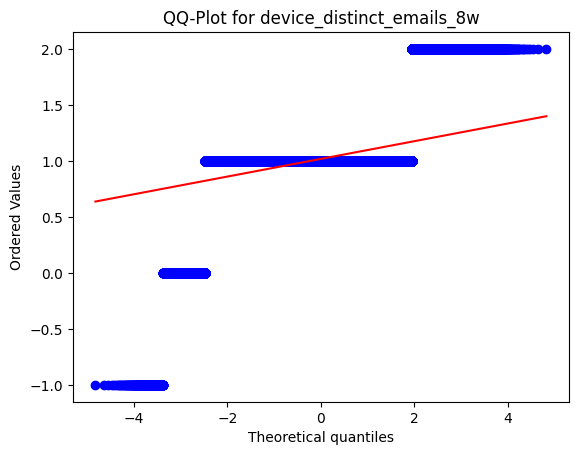

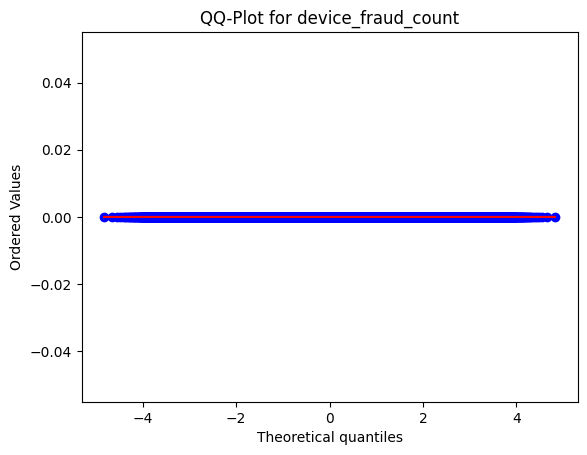

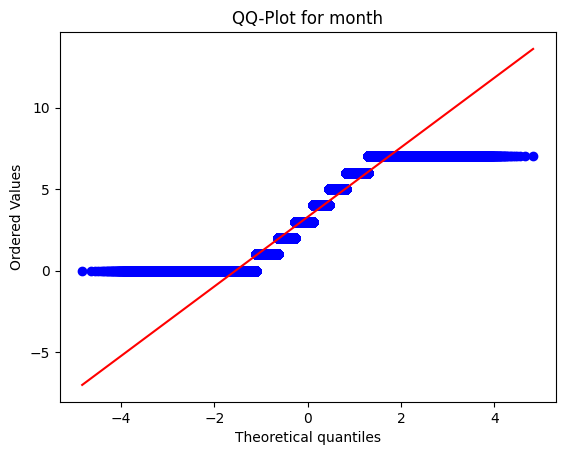

In [34]:
import scipy.stats as stats 


for i in numeric_columns:
    stats.probplot(df[i],dist="norm",plot = plt)
    plt.title(f"QQ-Plot for {i}")
    plt.show()

**Z - Score Calculation**

In [35]:
outlier_summary = pd.DataFrame(
    {
        "Features" : numeric_columns,
        "outliers" : [ np.mean(np.abs((df[col] - df[col].mean())/df[col].std()) > 3)  for col in  numeric_columns]
    }
)

outlier_summary.sort_values(by="outliers", ascending=False)

,Features,outliers
11,bank_branch_count_8w,0.040984
23,device_distinct_emails_8w,0.031933
2,prev_address_months_count,0.025310
20,foreign_request,0.025242
21,session_length_in_minutes,0.023593
3,current_address_months_count,0.021483
6,intended_balcon_amount,0.018960
5,days_since_request,0.017775
7,zip_count_4w,0.016247
4,customer_age,0.007890



---
### **1. Why use `abs()` (Absolute Value)?**

**Think of it like measuring distance from home:**

Imagine your home is at position 0. If you travel:
- **+5 km East** → you're 5 km away
- **-5 km West** → you're also 5 km away

**We care about HOW FAR you are, not WHICH DIRECTION!**

**In Z-scores:**
- Z-score of **+4** = value is 4 standard deviations ABOVE average (very high outlier)
- Z-score of **-4** = value is 4 standard deviations BELOW average (very low outlier)

**Without `abs()`:**
- We'd only catch the high outliers (+4)
- We'd MISS the low outliers (-4)

**With `abs()`:**
- |-4| = 4 and |+4| = 4
- We catch outliers on BOTH sides!

---

### **2. Why use threshold = 3?**

**This comes from the "68-95-99.7 Rule" of statistics:**

Imagine you have a bell curve (normal distribution). If data is normally distributed:

**The Rule:**
- **68%** of data falls within ±1 standard deviation
- **95%** of data falls within ±2 standard deviations  
- **99.7%** of data falls within ±3 standard deviations

**So if |Z-score| > 3:**
- Only **0.3%** of data should be this extreme
- These are RARE values → likely **outliers**!

**Why not use 2 or 4?**
- **Threshold = 2**: Catches ~5% of data (too many "false alarms")
- **Threshold = 3**: Catches ~0.3% of data (good balance) 
- **Threshold = 4**: Catches ~0.006% (too strict, might miss real outliers)

---


**Univariant relation between the numeric feature and Target variable**

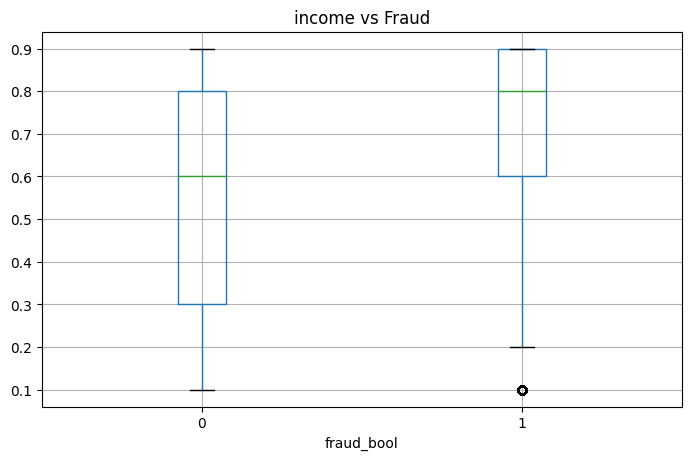

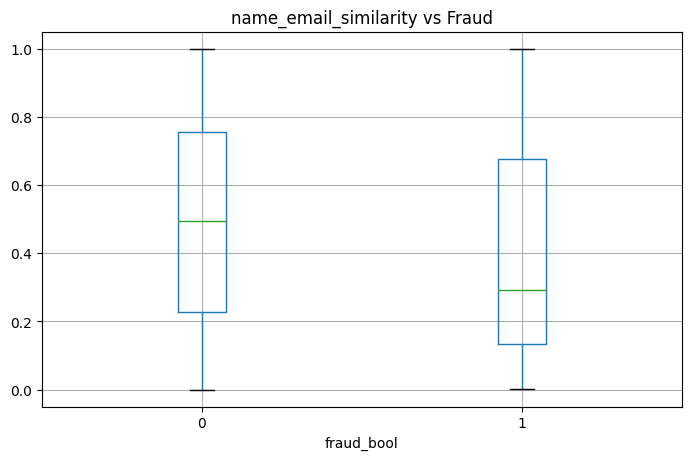

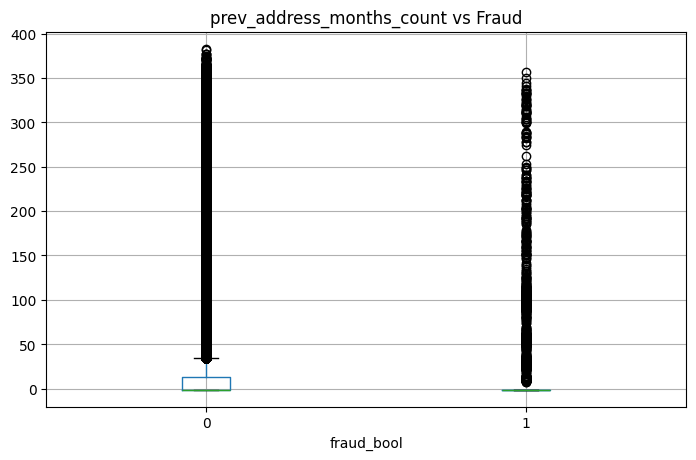

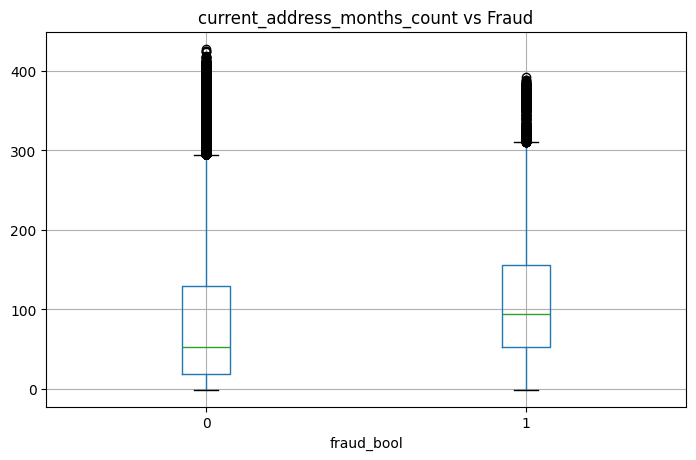

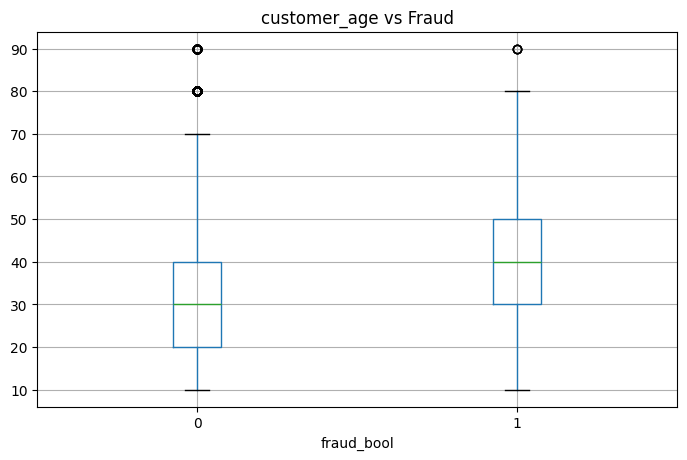

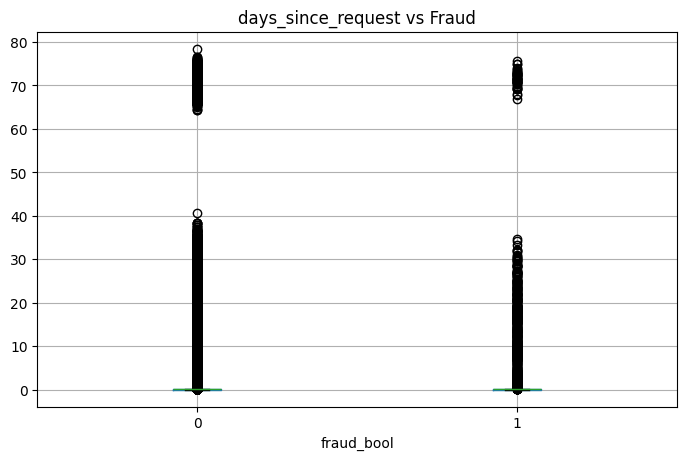

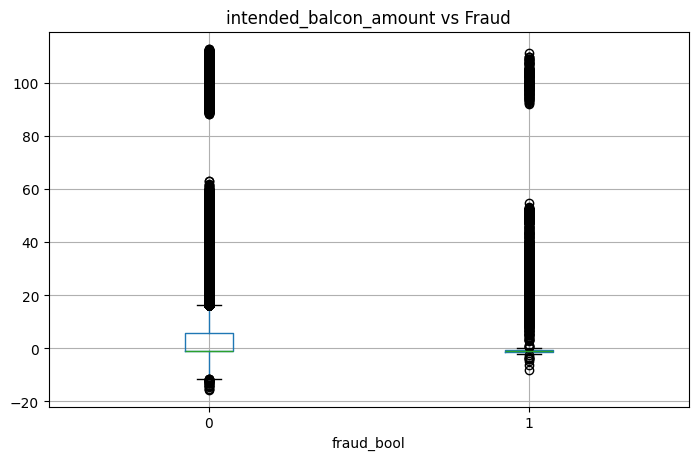

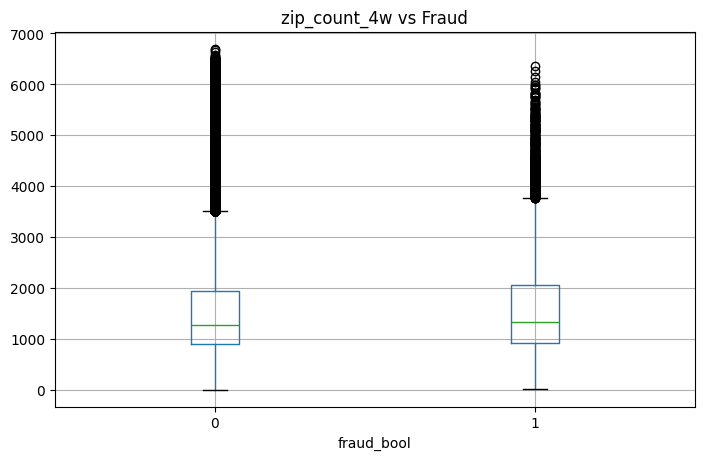

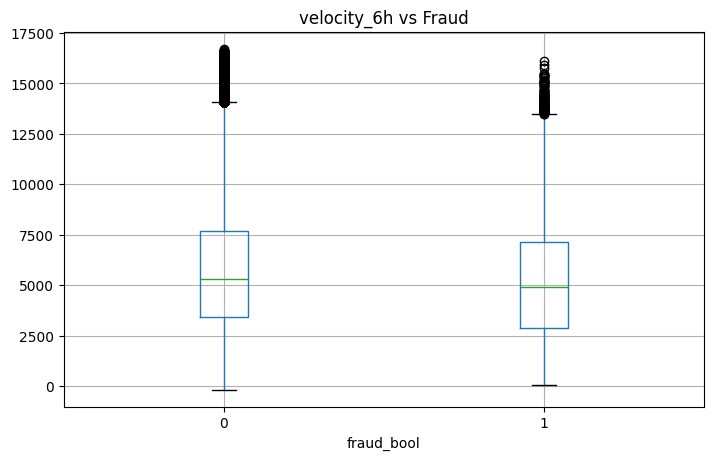

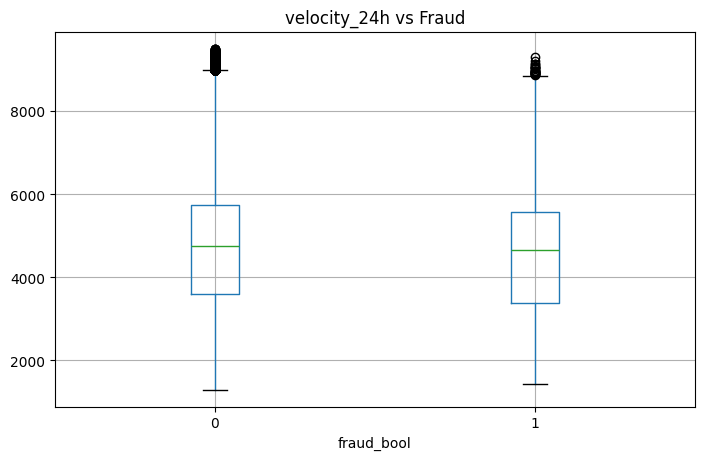

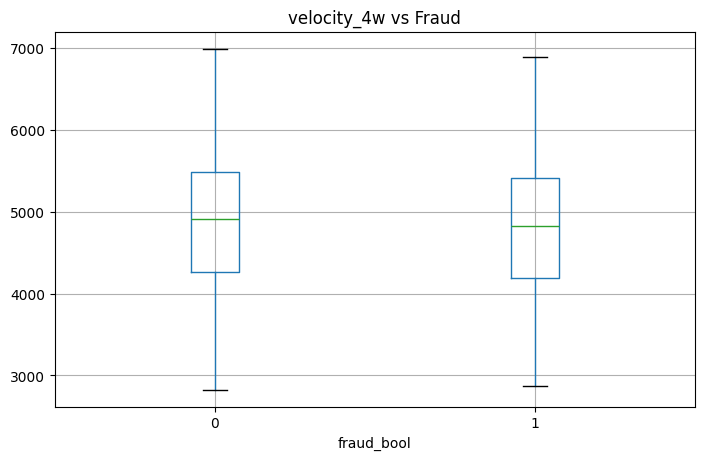

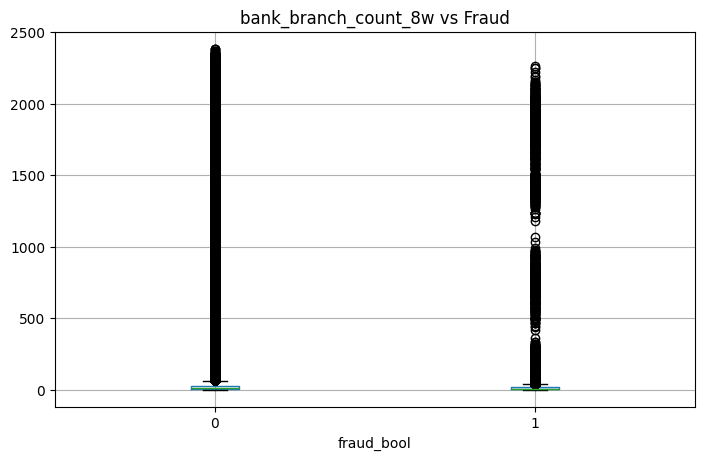

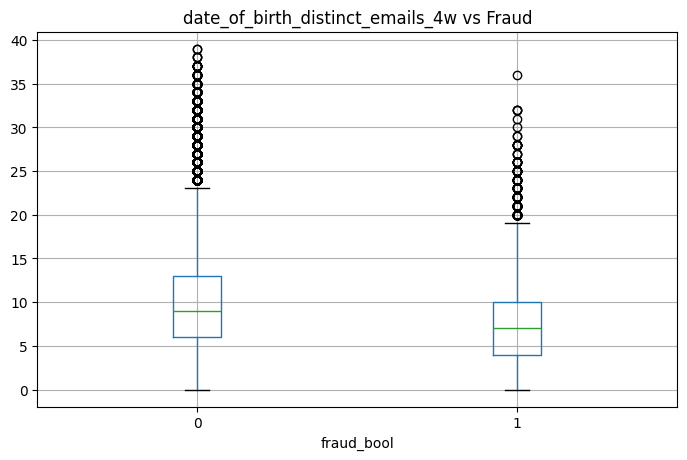

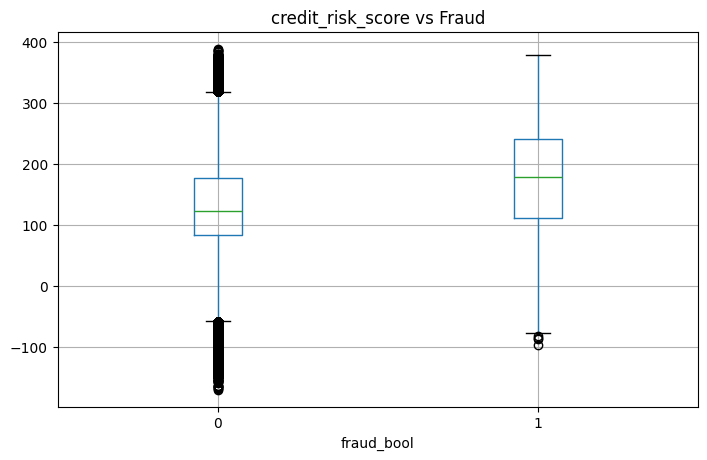

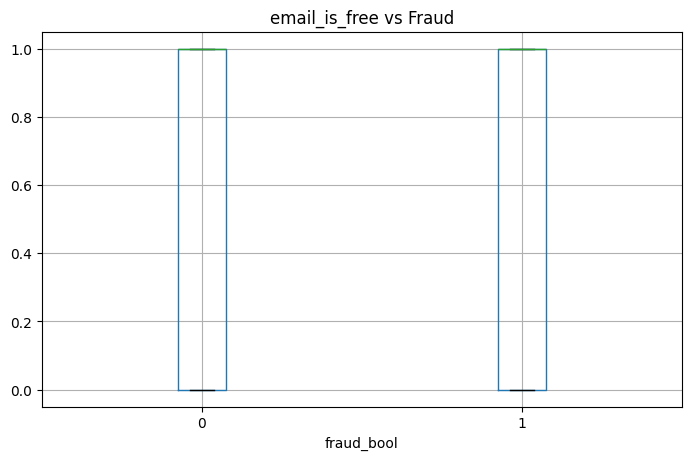

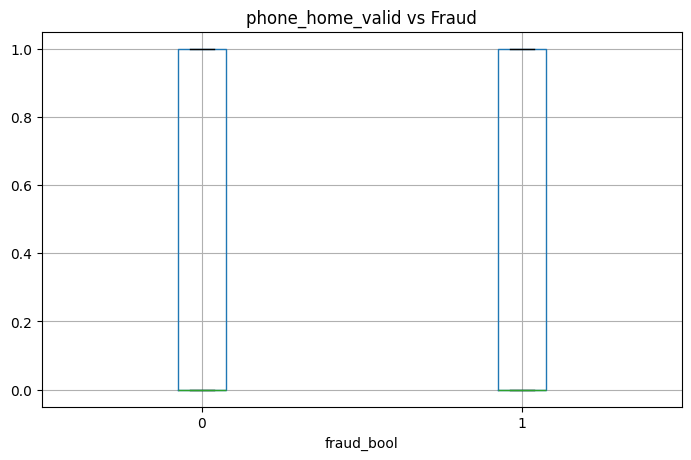

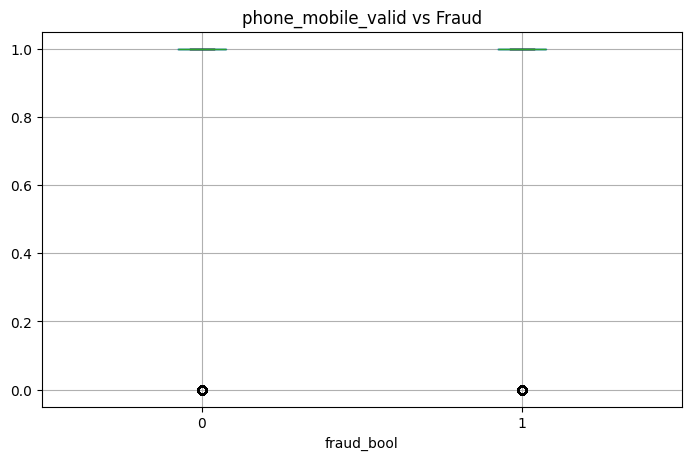

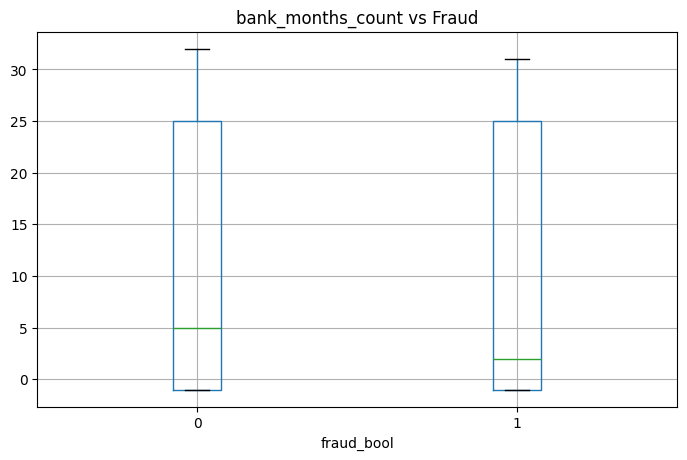

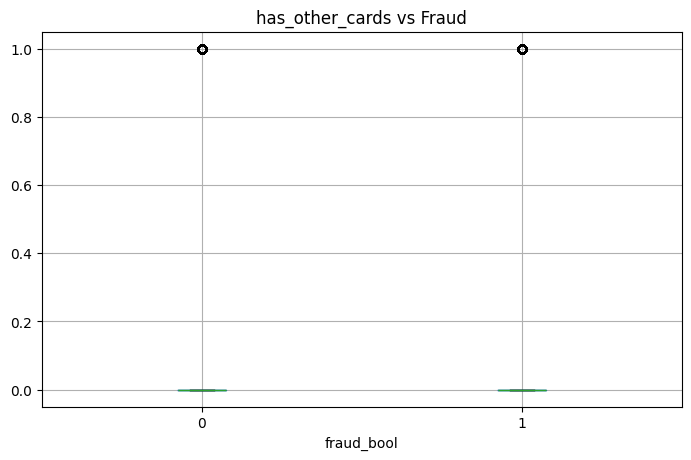

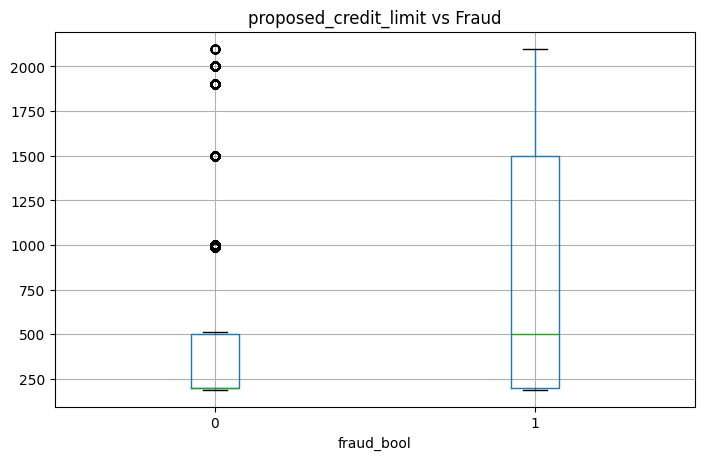

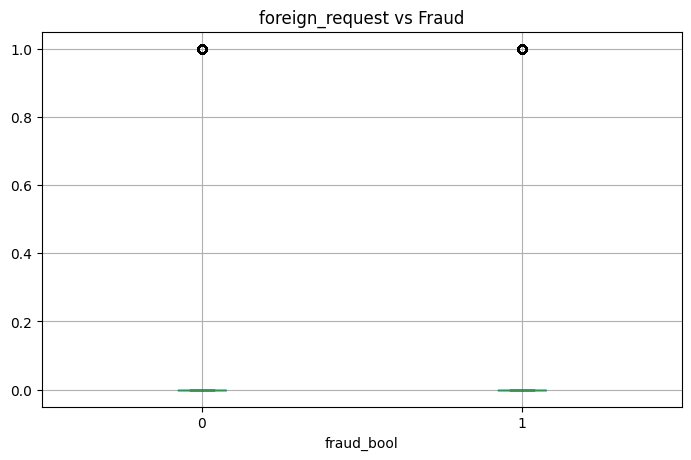

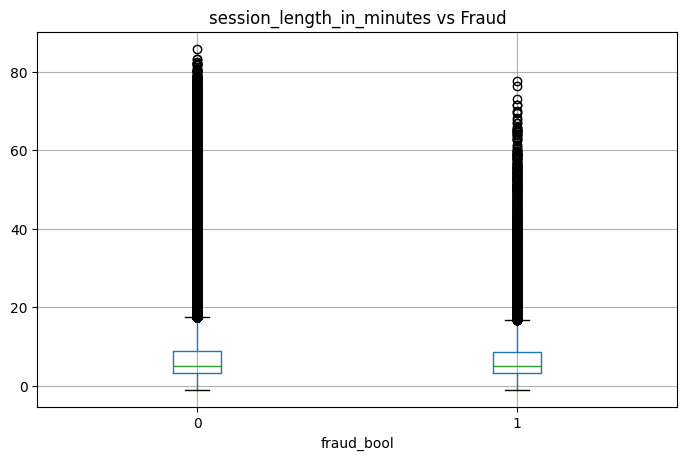

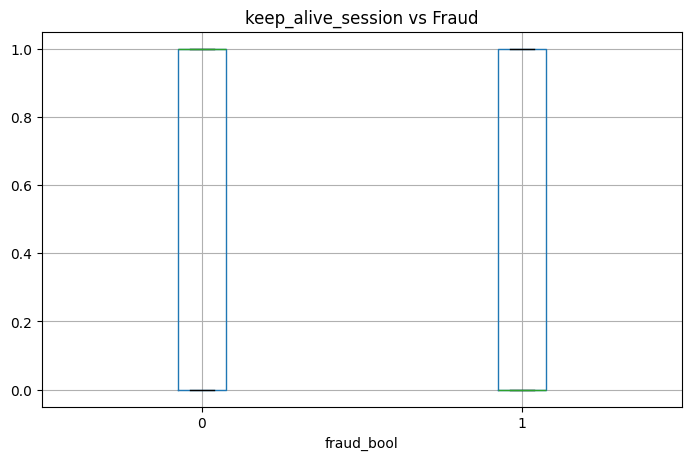

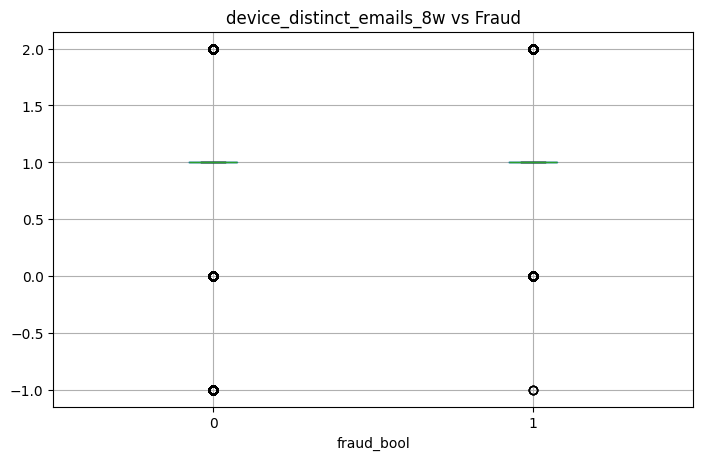

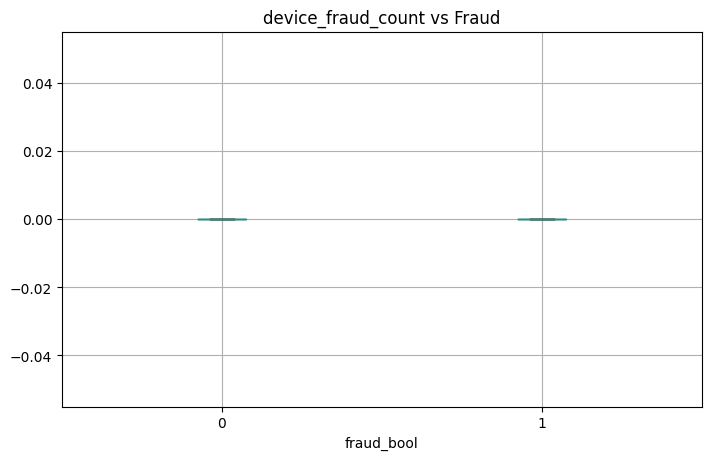

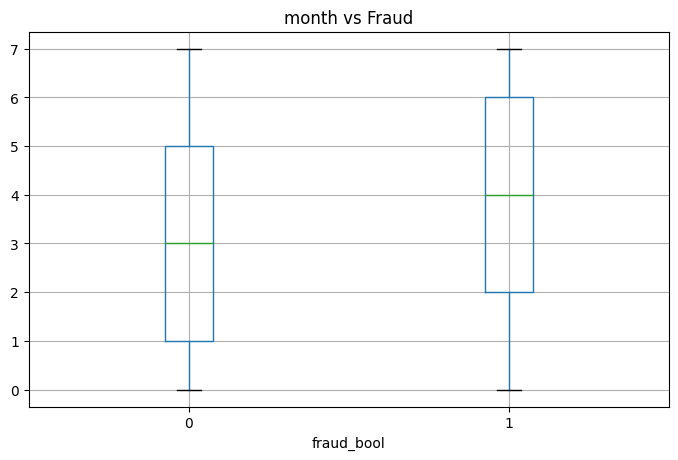

In [36]:
for  i in numeric_columns:
    df.boxplot(column=i, by='fraud_bool', figsize=(8, 5))
    plt.title(f"{i} vs Fraud")
    plt.suptitle('')  
    plt.show()

In [37]:
monthly_stats = df.groupby("month")[numeric_columns].mean()
px.line(monthly_stats, title="Monthly Mean of Numeric Features").show()


In [38]:
for col in numeric_columns:
    if df[df["fraud_bool"]==1][col].nunique() < df[df["fraud_bool"]==0][col].nunique() / 10:
        print("Suspicious feature:", col)


Suspicious feature: name_email_similarity
Suspicious feature: days_since_request
Suspicious feature: intended_balcon_amount
Suspicious feature: velocity_6h
Suspicious feature: velocity_24h
Suspicious feature: velocity_4w
Suspicious feature: session_length_in_minutes
